<a href="https://colab.research.google.com/github/pnistha11/retailinsights360/blob/main/RetailInsights360.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Retail Insights 360**

# Week 1 - – Load raw data and quick EDA


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
data = "/content/drive/MyDrive/Colab Notebooks/Superstore Sales/sample_-_superstore.xls"

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_excel(data)
print(df.head())

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   South  FUR-BO-10

In [8]:
df.shape
df.info()
df.isnull().sum()
df.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
4866,4867,CA-2017-122490,2017-11-13,2017-11-18,Standard Class,TT-21070,Ted Trevino,Consumer,United States,Seattle,...,98103,West,OFF-BI-10001718,Office Supplies,Binders,GBC DocuBind P50 Personal Binding Machine,563.024,11,0.2,190.0206
3717,3718,CA-2016-142370,2016-09-19,2016-09-23,Standard Class,TP-21130,Theone Pippenger,Consumer,United States,Columbus,...,31907,South,OFF-SU-10003002,Office Supplies,Supplies,Letter Slitter,5.040,2,0.0,0.1512
2091,2092,CA-2017-166142,2017-07-15,2017-07-19,Standard Class,MM-17260,Magdelene Morse,Consumer,United States,Wilmington,...,19805,East,FUR-TA-10004607,Furniture,Tables,Hon 2111 Invitation Series Straight Table,310.443,3,0.3,-48.7839
3246,3247,US-2017-140907,2017-12-10,2017-12-12,Second Class,BP-11185,Ben Peterman,Corporate,United States,Seattle,...,98103,West,OFF-ST-10000060,Office Supplies,Storage,Fellowes Bankers Box Staxonsteel Drawer File/S...,324.900,5,0.0,38.9880
9283,9284,CA-2017-102218,2017-09-02,2017-09-04,Second Class,LW-17215,Luke Weiss,Consumer,United States,Fort Collins,...,80525,West,OFF-LA-10002475,Office Supplies,Labels,Avery 519,11.696,2,0.2,3.9474


In [9]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [10]:
eda_summary = {
    "rows": df.shape[0],
    "columns": df.shape[1],
    "missing_values": df.isnull().sum().to_dict()
}

eda_summary


{'rows': 9994,
 'columns': 21,
 'missing_values': {'Row ID': 0,
  'Order ID': 0,
  'Order Date': 0,
  'Ship Date': 0,
  'Ship Mode': 0,
  'Customer ID': 0,
  'Customer Name': 0,
  'Segment': 0,
  'Country': 0,
  'City': 0,
  'State': 0,
  'Postal Code': 0,
  'Region': 0,
  'Product ID': 0,
  'Category': 0,
  'Sub-Category': 0,
  'Product Name': 0,
  'Sales': 0,
  'Quantity': 0,
  'Discount': 0,
  'Profit': 0}}

In [11]:
#raw data Saved
df.to_csv('superstore_raw.csv', index=False)

# Week 2 : Data profiling & business requirements

## **KPIs**


*  Revenue = Sales
*  Gross Margin = Sales − Profit
*  AOV = Sales / Orders
*  Conversion Proxy = Orders per customer





In [12]:
#Create base metrics
revenue = df['Sales'].sum()
profit = df['Profit'].sum()
orders = df['Order ID'].nunique()
customers = df['Customer ID'].nunique()
quantity = df['Quantity'].sum()

gross_margin = (profit / revenue) * 100
aov = revenue / orders
conversion_proxy = orders / customers

kpis = {
    "Revenue": revenue,
    "Profit": profit,
    "Gross Margin %": round(gross_margin, 2),
    "Average Order Value": round(aov, 2),
    "Quantity Sold": quantity,
    "Orders Count": orders,
    "Customer Count": customers,
    "Conversion Proxy": round(conversion_proxy, 2)
}

kpis

{'Revenue': np.float64(2297200.8603000003),
 'Profit': np.float64(286397.0216999999),
 'Gross Margin %': np.float64(12.47),
 'Average Order Value': np.float64(458.61),
 'Quantity Sold': np.int64(37873),
 'Orders Count': 5009,
 'Customer Count': 793,
 'Conversion Proxy': 6.32}

In [13]:
#Column list
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [14]:
#Unique values (dimension check)
df.nunique().sort_values(ascending=False)

,0
Row ID,9994
Profit,7545
Sales,6144
Order ID,5009
Product ID,1862
Product Name,1850
Ship Date,1334
Order Date,1237
Customer ID,793
Customer Name,793


In [15]:
#Date range check
df['Order Date'].min(), df['Order Date'].max()

(Timestamp('2014-01-03 00:00:00'), Timestamp('2017-12-30 00:00:00'))

In [ ]:
#Numeric profiling
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


In [16]:
#Categorical profiling
df['Category'].value_counts()
df['Region'].value_counts()
df['Segment'].value_counts()

,count
Segment,
Consumer,5191
Corporate,3020
Home Office,1783


# Week 3 — Data cleaning & small fixes

In [17]:
df = df.copy()

In [18]:
#KPI cleaning
def calculate_kpis(data):
    return {
        "Rows": data.shape[0],
        "Revenue": round(data['Sales'].sum(), 2),
        "Profit": round(data['Profit'].sum(), 2),
        "Orders": data['Order ID'].nunique(),
        "Customers": data['Customer ID'].nunique(),
        "Quantity": data['Quantity'].sum()
    }

kpi_before = calculate_kpis(df)
kpi_before

{'Rows': 9994,
 'Revenue': np.float64(2297200.86),
 'Profit': np.float64(286397.02),
 'Orders': 5009,
 'Customers': 793,
 'Quantity': np.int64(37873)}

In [19]:
#Check duplicates
df.duplicated().sum()

#Remove duplicates
df = df.drop_duplicates()

In [20]:
#Identify negative quantities
df[df['Quantity'] <= 0].head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


In [21]:
#clean
df = df[df['Quantity'] > 0]

In [22]:
#HANDLE EXTREME OR INVALID SALES VALUES
df = df[df['Sales'] >= 0]

### DATE PARSING & TIMESTAMP FIX

In [23]:
#Check date types
df[['Order Date', 'Ship Date']].dtypes

,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


In [24]:
#Convert to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [25]:
#Remove invalid dates
df = df.dropna(subset=['Order Date', 'Ship Date'])

In [26]:
#CREATE DATE FEATURES
df['order_year'] = df['Order Date'].dt.year
df['order_month'] = df['Order Date'].dt.month
df['order_day'] = df['Order Date'].dt.day

In [27]:
#Convert to lowercase & strip spaces
text_cols = ['Category', 'Sub-Category', 'Region', 'Segment', 'Country', 'State', 'City']

for col in text_cols:
    df[col] = df[col].str.strip().str.lower()

In [28]:
#STANDARDIZE CATEGORY NAMES
df['Category'].value_counts()

,count
Category,
office supplies,6026
furniture,2121
technology,1847


In [29]:
kpi_after = calculate_kpis(df)
kpi_after

{'Rows': 9994,
 'Revenue': np.float64(2297200.86),
 'Profit': np.float64(286397.02),
 'Orders': 5009,
 'Customers': 793,
 'Quantity': np.int64(37873)}

In [30]:
comparison_df = pd.DataFrame([kpi_before, kpi_after], index=['Before Cleaning', 'After Cleaning'])
comparison_df

,Rows,Revenue,Profit,Orders,Customers,Quantity
Before Cleaning,9994,2297200.86,286397.02,5009,793,37873
After Cleaning,9994,2297200.86,286397.02,5009,793,37873


In [31]:
#SAVE CLEANED DATASET
import os

os.makedirs("data/cleaned", exist_ok=True)
df.to_csv("data/cleaned/superstore_cleaned.csv", index=False)
df.to_csv("superstore_cleaned.csv", index=False)

In [32]:
#checking for data quality
assert df.isnull().sum().sum() == 0
assert df['Quantity'].min() > 0
assert df['Sales'].min() >= 0

In [33]:
df.shape

(9994, 24)

# Model Selection & Training

In [34]:
# Target variable
y = df['Sales']

# Feature columns
X = df[['Quantity', 'Discount', 'Category', 'Sub-Category', 'Segment', 'Region']]

In [35]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_cols = ['Category', 'Sub-Category', 'Segment', 'Region']
numeric_cols = ['Quantity', 'Discount']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)

## Train - Test Split

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Build & Train ML Model

In [37]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

# Train model
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Category', 'Sub-Category',
                                                   'Segment', 'Region']),
                                                 ('num', 'passthrough',
                                                  ['Quantity', 'Discount'])])),
                ('regressor',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=42))])

## Model Evaluation

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 210.89657982395053
RMSE: 700.9031358555684
R2  : 0.1683326525831007


## Feature Importance


In [48]:
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
importances = model.named_steps['regressor'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

importance_df.head(10)

,Feature,Importance
27,num__Quantity,0.284970
28,num__Discount,0.128075
9,cat__Sub-Category_copiers,0.127913
23,cat__Region_central,0.059995
14,cat__Sub-Category_machines,0.049215
20,cat__Segment_consumer,0.047866
1,cat__Category_office supplies,0.042683
24,cat__Region_east,0.038772
21,cat__Segment_corporate,0.031948
22,cat__Segment_home office,0.031794


## MAE – Mean Absolute Error

In [40]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 210.89657982395053


### RMSE – Root Mean Squared Error

In [41]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 700.9031358555684


## R² Score

In [42]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.1683326525831007


In [43]:
accuracy_like = 1 - (mae / y_test.mean())
print("Approx Accuracy:", accuracy_like * 100, "%")

Approx Accuracy: 14.525403095988098 %


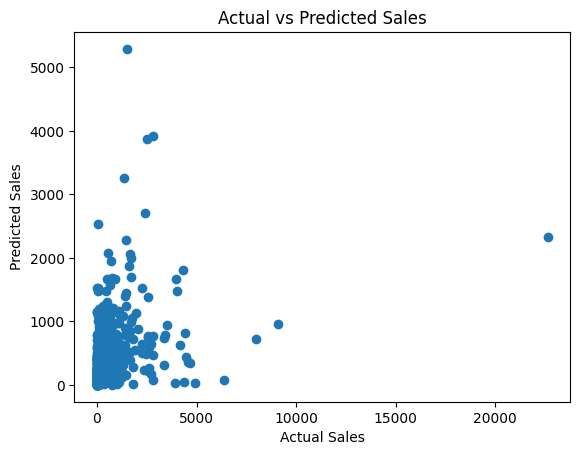

In [45]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()